In [1]:
import os
import sys
import json
import pickle
import argparse
import threading
import yara
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path


In [2]:

def plot_cluster_std_dev_boxplot_static_all(dfs, drop_smallest_n=0, output_file='cluster_std_dev_boxplot_all.pdf'):
    """
    Plot boxplots for False Possitivess by cluster size across multiple DataFrames,
    dropping the specified number of smallest cluster sizes, using the same x-axis (cluster sizes) with
    ticks at intervals of 100 applied to all subplots, leaving blank spaces for missing sizes,
    with a shared y-axis scale, and superimpose both the cumulative moving average (red) and a
    sliding window average (window size 5, blue) of the median on the same subplot.

    Parameters:
    - dfs: List of 5 pandas DataFrames
    - drop_smallest_n: Integer, number of smallest cluster sizes to drop (default: 0)
    - output_file: File path to save the output PDF
    """
    if not all(isinstance(df, pd.DataFrame) for df in dfs):
        raise ValueError("All items in input list must be pandas DataFrames")
    if len(dfs) != 5:
        raise ValueError("Expected exactly 5 DataFrames")
    if not isinstance(drop_smallest_n, int) or drop_smallest_n < 0:
        raise ValueError("drop_smallest_n must be a non-negative integer")

    titles = ['Th50', 'Th60', 'Th70', 'Th80', 'Th90']
    fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(12, 18), sharex=True, sharey=True)
    fig.subplots_adjust(hspace=0.4)

    global_min = float('inf')
    global_max = float('-inf')

    all_sizes = set()
    for df in dfs:
        df = df.replace('None', np.nan).apply(pd.to_numeric, errors='coerce')
        try:
            sizes = df.columns.astype(int).tolist()
            all_sizes.update(sizes)
        except ValueError:
            continue

    all_sizes = sorted(list(all_sizes))
    if not all_sizes:
        raise ValueError("No valid cluster sizes found in any DataFrame")

    if drop_smallest_n > 0:
        if len(all_sizes) > drop_smallest_n:
            sizes_to_drop = all_sizes[:drop_smallest_n]
            all_sizes = all_sizes[drop_smallest_n:]
            print(f"Dropping the smallest {drop_smallest_n} cluster sizes: {sizes_to_drop}")
        else:
            print(f"Requested to drop {drop_smallest_n} sizes, but only {len(all_sizes)} available; all sizes dropped")
            all_sizes = []

    if not all_sizes:
        raise ValueError("No cluster sizes remain after dropping")

    filtered_dfs = []
    for df in dfs:
        df = df.replace('None', np.nan).apply(pd.to_numeric, errors='coerce')
        remaining_columns = [col for col in df.columns if int(col) in all_sizes]
        filtered_df = df[remaining_columns]
        filtered_dfs.append(filtered_df)

    max_size = max(all_sizes)
    min_size = min(all_sizes)
    tick_start = (min_size // 100) * 100
    tick_sizes = list(range(tick_start, max_size + 100, 100))
    tick_positions = []
    for tick in tick_sizes:
        closest_idx = min(range(len(all_sizes)), key=lambda i: abs(all_sizes[i] - tick))
        tick_positions.append(closest_idx + 1)

    for df in filtered_dfs:
        for size in all_sizes:
            if str(size) in df.columns:
                data = df[str(size)].dropna().tolist()
                if data:
                    global_min = min(global_min, min(data))
                    global_max = max(global_max, max(data))

    if global_min == float('inf') or global_max == float('-inf'):
        global_min, global_max = 0, 1
    else:
        padding = (global_max - global_min) * 0.05
        global_min -= padding
        global_max += padding

    for i, (df, ax) in enumerate(zip(filtered_dfs, axs)):
        datasets = []
        sizes_with_data = []
        for size in all_sizes:
            if str(size) in df.columns:
                data = df[str(size)].dropna().tolist()
                datasets.append(data)
                if data:
                    sizes_with_data.append(size)
            else:
                datasets.append([])

        if not any(datasets):
            ax.set_title(f'{titles[i]}: No valid data')
            ax.set_ylabel('False Possitives')
            ax.set_xlabel('Cluster Size (Number of Items)')
            print(f"Subplot {titles[i]}: No valid data to plot")
            continue

        print(f"Subplot {titles[i]}: sizes_with_data = {sizes_with_data[:10]}... (length: {len(sizes_with_data)})")

        box = ax.boxplot(datasets, positions=range(1, len(all_sizes) + 1), 
                         labels=[str(s) for s in all_sizes], patch_artist=True)

        medians = [np.median(d) if d else np.nan for d in datasets]
        valid_medians = [m for m in medians if not np.isnan(m)]
        valid_positions = [i + 1 for i, d in enumerate(datasets) if d]

        if valid_medians:
            cumulative_avg = np.cumsum(valid_medians) / np.arange(1, len(valid_medians) + 1)
            ax.plot(valid_positions[:len(cumulative_avg)], cumulative_avg, color='red', marker='o', 
                    label='Cumulative Avg of Median', linestyle='-', linewidth=2)

            window_size = 5
            sliding_avg = []
            for j in range(len(valid_medians)):
                start = max(0, j - window_size + 1)
                window = valid_medians[start:j + 1]
                sliding_avg.append(np.mean(window))
            ax.plot(valid_positions[:len(sliding_avg)], sliding_avg, color='blue', marker='s', 
                    label='Sliding Window Avg (size 5)', linestyle='--', linewidth=2)

            ax.legend()

        ax.set_title(titles[i])
        ax.set_ylabel('False Possitives')
        ax.set_xlabel('Cluster Size (Number of Items)')
        ax.set_ylim(global_min, global_max)

    if tick_positions:
        axs[-1].set_xticks(tick_positions)
        axs[-1].set_xticklabels([str(tick) for tick in tick_sizes])
        print(f"Setting x-ticks on last subplot: {tick_sizes} (positions: {tick_positions})")
    else:
        print("No valid tick positions found")

    plt.tight_layout()
    fig.savefig(output_file, format='pdf')
    plt.close(fig)


def build(df, df_cluster, filtered_clustersM):
    # Dictionary to track the number of values assigned to each cluster_loc
    row_tracker = {col: 0 for col in df_cluster.columns}
    
    # Iterate through the mapping in filtered_clustersM
    for cluster_id, cluster_loc in filtered_clustersM.items():
        # Check if cluster_id exists in df's index
        if cluster_id in df.index:
            # Calculate the mean value from df for the cluster_id
            mean_value = df.loc[cluster_id].mean()
            #print(mean_value, cluster_id, cluster_loc)
            
            # Ensure cluster_loc is a valid column in df_cluster
            if cluster_loc in df_cluster.columns:
                # Get the current row index for this cluster_loc
                current_row = row_tracker[cluster_loc]
                
                # If current_row >= number of rows in df_cluster, add a new row
                if current_row >= len(df_cluster):
                    df_cluster.loc[current_row] = [None] * len(df_cluster.columns)
                
                # Assign the mean_value to the cell in df_cluster at current_row, cluster_loc
                df_cluster.at[current_row, cluster_loc] = mean_value
                
                # Increment the row tracker for this cluster_loc
                row_tracker[cluster_loc] += 1
            else:
                print(f"Column {cluster_loc} not found in df_cluster")
    return df_cluster  # Exit after processing the first valid cluster_id

In [6]:
csv = [
    "/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Random/sdhashRTBF_TH50.csv",
    "/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Random/sdhashRTBF_TH60.csv",
    "/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Random/sdhashRTBF_TH70.csv",
    "/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Random/sdhashRTBF_TH80.csv",
    "/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Random/sdhashRTBF_TH90.csv"
]
df_Load = []

for file in csv:
    print(file)
    dataframe = pd.read_csv(file)
    dataframe = dataframe.drop('File_Name', axis=1)
    df_Load.append(dataframe)

csv_file=['/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th50.csv',
          '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th60.csv',
          '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th70.csv',
          '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th80.csv',
          '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th90.csv']

        
filtered_clustersM=[]
df_cluster=[] 

for file in csv_file:
    df1 = pd.read_csv(file)
    labels = df1['Cluster_Label'].dropna().astype(int)
    
    # Count cluster sizes
    cluster_sizes = labels[labels >= 0].value_counts()
    
    # Filter clusters with size >= 2
    filtered_clusters = cluster_sizes[cluster_sizes >= 2]
    filtered_clustersM.append(filtered_clusters.to_dict())
    # Create empty DataFrame with columns = unique cluster sizes
    unique_sizes = sorted(filtered_clusters.unique())
    df_new = pd.DataFrame(columns=unique_sizes)
    df_cluster.append(df_new)  
   
df_cluster_updated=[]
for i in range(5):
    print(i)
    df_cluster_updated.append(build(df_Load[i], df_cluster[i], filtered_clustersM[i]))
    
    df_cluster_updated[i].columns = df_cluster_updated[i].columns.astype(str)


/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Random/sdhashRTBF_TH50.csv
/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Random/sdhashRTBF_TH60.csv
/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Random/sdhashRTBF_TH70.csv
/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Random/sdhashRTBF_TH80.csv
/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Random/sdhashRTBF_TH90.csv
0
1
2
3
4


In [7]:

# Replace df_cluster_updated with your actual list of DataFrames
all_data = pd.concat(df_cluster_updated, ignore_index=True)

# Flatten and clean the data
values = all_data.values.flatten()
values = values[~pd.isna(values)]  # Remove None/NaN values

# Calculate mean and standard deviation
mean_value = np.mean(values) * 100
std_value = np.std(values) * 100

# Print LaTeX-formatted result
print(f" ${mean_value:.4f} \\pm {std_value:.4f}$")

 $0.0213 \pm 0.0185$


In [8]:
csv = [
    "/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Max/sdhashRTBF_TH50.csv",
    "/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Max/sdhashRTBF_TH60.csv",
    "/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Max/sdhashRTBF_TH70.csv",
    "/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Max/sdhashRTBF_TH80.csv",
    "/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Max/sdhashRTBF_TH90.csv"
]
df_Load = []

for file in csv:
    print(file)
    dataframe = pd.read_csv(file)
    dataframe = dataframe.drop('File_Name', axis=1)
    df_Load.append(dataframe)

csv_file=['/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th50.csv',
          '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th60.csv',
          '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th70.csv',
          '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th80.csv',
          '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th90.csv']

        
filtered_clustersM=[]
df_cluster=[] 

for file in csv_file:
    df1 = pd.read_csv(file)
    labels = df1['Cluster_Label'].dropna().astype(int)
    
    # Count cluster sizes
    cluster_sizes = labels[labels >= 0].value_counts()
    
    # Filter clusters with size >= 2
    filtered_clusters = cluster_sizes[cluster_sizes >= 2]
    filtered_clustersM.append(filtered_clusters.to_dict())
    # Create empty DataFrame with columns = unique cluster sizes
    unique_sizes = sorted(filtered_clusters.unique())
    df_new = pd.DataFrame(columns=unique_sizes)
    df_cluster.append(df_new)  
   
df_cluster_updated=[]
for i in range(5):
    print(i)
    df_cluster_updated.append(build(df_Load[i], df_cluster[i], filtered_clustersM[i]))
    
    df_cluster_updated[i].columns = df_cluster_updated[i].columns.astype(str)


/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Max/sdhashRTBF_TH50.csv
/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Max/sdhashRTBF_TH60.csv
/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Max/sdhashRTBF_TH70.csv
/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Max/sdhashRTBF_TH80.csv
/home/mabon/research/Autoyara/YaraResults/ruleEval/retrainedBloomFilters/sdhash/AutoPYara/GoodwareEval/Heuristic/VTHeu/Max/sdhashRTBF_TH90.csv
0
1
2
3
4


In [9]:

# Replace df_cluster_updated with your actual list of DataFrames
all_data = pd.concat(df_cluster_updated, ignore_index=True)

# Flatten and clean the data
values = all_data.values.flatten()
values = values[~pd.isna(values)]  # Remove None/NaN values

# Calculate mean and standard deviation
mean_value = np.mean(values) * 100
std_value = np.std(values) * 100

# Print LaTeX-formatted result
print(f" ${mean_value:.4f} \\pm {std_value:.4f}$")

 $0.0332 \pm 0.0363$


In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Plot Styling Configuration
# ============================

# Global font settings
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.weight': 600,
    'font.size': 28
})

# Custom style constants
AXIS_FONT = {'family': 'DejaVu Sans', 'weight': 600, 'size': 28}
TITLE_FONT = {'family': 'DejaVu Sans', 'weight': 600, 'size': 22}
TICK_FONT = {'fontsize': 28, 'fontweight': 'bold'}

# Custom tick sizes to be shown on x-axis
TICK_SIZES = [0, 25, 50, 75, 100, 500]

# ============================
# Main Plotting Function
# ============================

def plot_cluster_std_dev_boxplot_single(
    dfs, drop_smallest_n=0, output_file='cluster_std_dev_boxplot_single.pdf'
):
    """
    Plot a single boxplot for False Positives by cluster size across a single DataFrame,
    dropping the specified number of smallest cluster sizes, and overlaying cumulative
    and sliding averages of the medians.
    """
    # Input validation
    if not all(isinstance(df, pd.DataFrame) for df in dfs):
        raise ValueError("All items in input list must be pandas DataFrames")
    if len(dfs) != 1:
        raise ValueError("Expected exactly 1 DataFrame in the list")
    if not isinstance(drop_smallest_n, int) or drop_smallest_n < 0:
        raise ValueError("drop_smallest_n must be a non-negative integer")

    # Extract valid cluster sizes from column names
    all_sizes = set()
    for df in dfs:
        df = df.replace('None', np.nan).apply(pd.to_numeric, errors='coerce')
        try:
            sizes = df.columns.astype(int).tolist()
            all_sizes.update(sizes)
        except ValueError:
            continue
    all_sizes = sorted(list(all_sizes))

    if drop_smallest_n > 0:
        if len(all_sizes) > drop_smallest_n:
            print(f"Dropping the smallest {drop_smallest_n} cluster sizes: {all_sizes[:drop_smallest_n]}")
            all_sizes = all_sizes[drop_smallest_n:]
        else:
            raise ValueError(f"Not enough cluster sizes to drop {drop_smallest_n}")

    if not all_sizes:
        raise ValueError("No cluster sizes remain after dropping")

    # Aggregate data
    combined_data = []
    for size in all_sizes:
        size_data = []
        for df in dfs:
            if str(size) in df.columns:
                size_data.extend(df[str(size)].dropna().tolist())
        combined_data.append(size_data)

    # Compute y-axis limits
    global_min, global_max = float('inf'), float('-inf')
    for data in combined_data:
        if data:
            global_min = min(global_min, min(data))
            global_max = max(global_max, max(data))

    if global_min == float('inf') or global_max == float('-inf'):
        global_min, global_max = 0, 1
    else:
        pad = (global_max - global_min) * 0.05
        global_min -= pad
        global_max += pad

    # Plotting
    fig, ax = plt.subplots(figsize=(18, 8))

    if not any(combined_data):
        ax.set_title('No valid data', fontdict=TITLE_FONT)
        ax.set_ylabel('False Positives', fontdict=AXIS_FONT)
        ax.set_xlabel('Cluster Size (Number of Items)', fontdict=AXIS_FONT)
        print("No valid data to plot")
    else:
        sizes_with_data = [s for s, d in zip(all_sizes, combined_data) if d]
        print(f"Plotting sizes_with_data = {sizes_with_data[:10]}... (length: {len(sizes_with_data)})")

        ax.boxplot(combined_data, positions=range(1, len(all_sizes) + 1),
                   labels=[str(s) for s in all_sizes], patch_artist=True)

        # Overlay median statistics
        medians = [np.median(d) if d else np.nan for d in combined_data]
        valid_medians = [m for m in medians if not np.isnan(m)]
        valid_positions = [i + 1 for i, d in enumerate(combined_data) if d]

        if valid_medians:
            cumulative_avg = np.cumsum(valid_medians) / np.arange(1, len(valid_medians) + 1)
            ax.plot(valid_positions[:len(cumulative_avg)], cumulative_avg, color='red', marker='o',
                    label='Cumulative Avg of Median', linestyle='-', linewidth=2)

            window_size = 5
            sliding_avg = [np.mean(valid_medians[max(0, i - window_size + 1):i + 1])
                           for i in range(len(valid_medians))]
            ax.plot(valid_positions[:len(sliding_avg)], sliding_avg, color='blue', marker='s',
                    label='Sliding Window Avg', linestyle='--', linewidth=2)

            ax.legend()

        ax.set_ylabel('False Positives (%)', fontdict=AXIS_FONT)
        ax.set_xlabel('Cluster Size (Number of Items)', fontdict=AXIS_FONT)
        ax.set_ylim(0, 100)

        # Custom x-tick positions
        tick_positions = []
        for tick in TICK_SIZES:
            if all_sizes:
                closest_idx = min(range(len(all_sizes)), key=lambda i: abs(all_sizes[i] - tick))
                tick_positions.append(closest_idx + 1)
        ax.set_xticks(tick_positions)
        ax.set_xticklabels([str(t) for t in TICK_SIZES], **TICK_FONT)

    fig.savefig(output_file, format='pdf')
    plt.show()
    plt.close(fig)


In [143]:
df_cluster_updated[0]=df_cluster_updated[0]*100

Plotting sizes_with_data = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]... (length: 135)


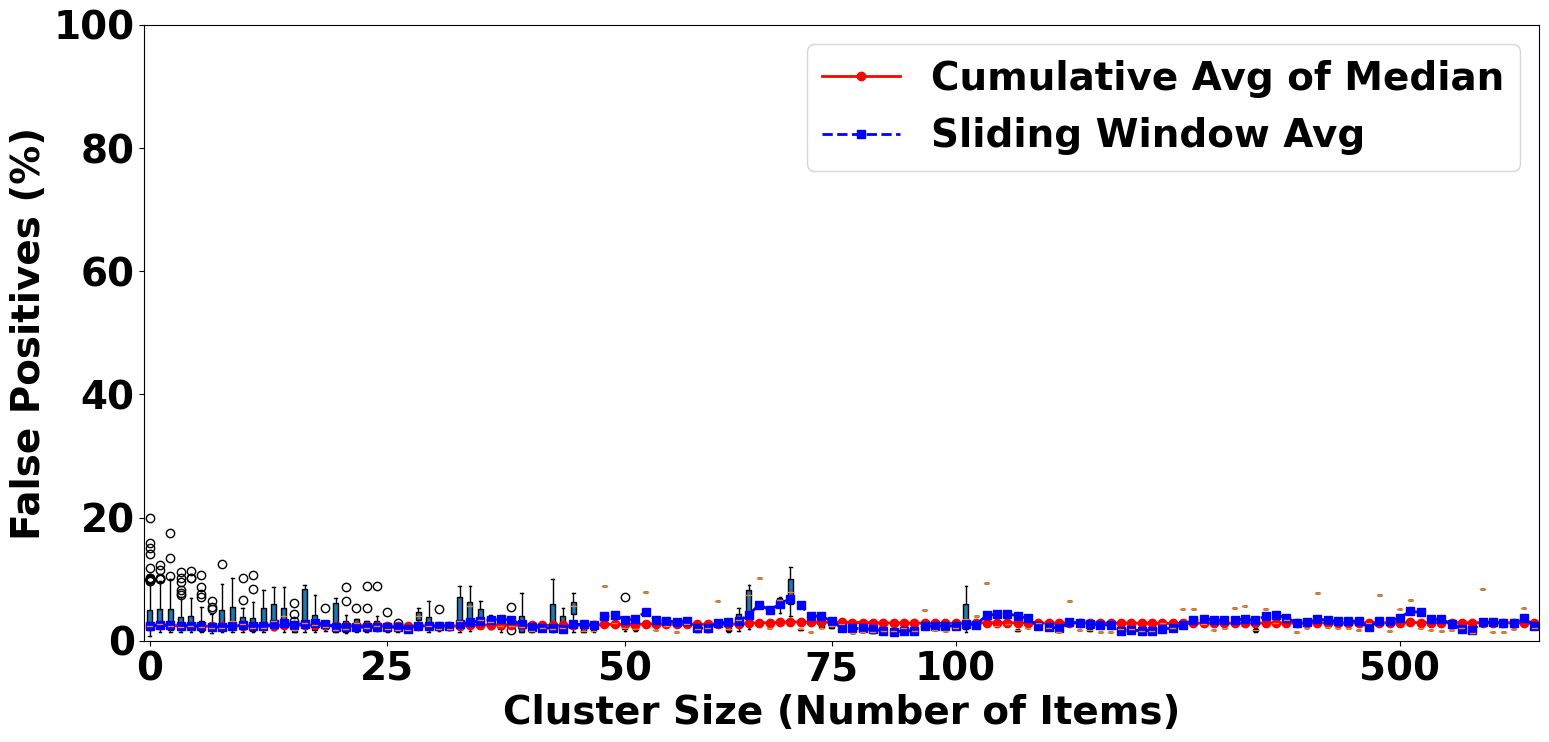

In [144]:
plot_cluster_std_dev_boxplot_single(df_cluster_updated, drop_smallest_n=0, output_file='possibley an evil think2.pdf')